In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
d1 = pd.read_csv('Part2 - Data1.csv')

In [3]:
d2 = pd.read_csv('Part2 -Data2.csv')

In [4]:
d1.head()

,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level
0,1,25,1,49,91107,4,1.6,1
1,2,45,19,34,90089,3,1.5,1
2,3,39,15,11,94720,1,1.0,1
3,4,35,9,100,94112,1,2.7,2
4,5,35,8,45,91330,4,1.0,2


In [5]:
d1.shape

(5000, 8)

In [6]:
d2.head()

,ID,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,1,0,1,0,0,0,NaN
1,2,0,1,0,0,0,NaN
2,3,0,0,0,0,0,NaN
3,4,0,0,0,0,0,NaN
4,5,0,0,0,0,1,NaN


In [7]:
d2.shape

(5000, 7)

In [8]:
df = pd.merge(d1,d2,on='ID',how='inner')

In [9]:
df.head()

,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,1,25,1,49,91107,4,1.6,1,0,1,0,0,0,NaN
1,2,45,19,34,90089,3,1.5,1,0,1,0,0,0,NaN
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,NaN
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,NaN
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,1,NaN


In [10]:
df.size

70000

In [11]:
df.shape

(5000, 14)

#### Data Cleansing :

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   5000 non-null   int64  
 1   Age                  5000 non-null   int64  
 2   CustomerSince        5000 non-null   int64  
 3   HighestSpend         5000 non-null   int64  
 4   ZipCode              5000 non-null   int64  
 5   HiddenScore          5000 non-null   int64  
 6   MonthlyAverageSpend  5000 non-null   float64
 7   Level                5000 non-null   int64  
 8   Mortgage             5000 non-null   int64  
 9   Security             5000 non-null   int64  
 10  FixedDepositAccount  5000 non-null   int64  
 11  InternetBanking      5000 non-null   int64  
 12  CreditCard           5000 non-null   int64  
 13  LoanOnCard           4980 non-null   float64
dtypes: float64(2), int64(12)
memory usage: 585.9 KB


In [13]:
df.describe()

,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,4980.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.104400,0.06040,0.596800,0.294000,0.096386
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.305809,0.23825,0.490589,0.455637,0.295149
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.00000,1.000000,1.000000,0.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.00000,1.000000,1.000000,1.000000


In [14]:
df.isna().sum()

ID                      0
Age                     0
CustomerSince           0
HighestSpend            0
ZipCode                 0
HiddenScore             0
MonthlyAverageSpend     0
Level                   0
Mortgage                0
Security                0
FixedDepositAccount     0
InternetBanking         0
CreditCard              0
LoanOnCard             20
dtype: int64

In [15]:
df.dropna(inplace=True)

In [16]:
df.isna().sum()

ID                     0
Age                    0
CustomerSince          0
HighestSpend           0
ZipCode                0
HiddenScore            0
MonthlyAverageSpend    0
Level                  0
Mortgage               0
Security               0
FixedDepositAccount    0
InternetBanking        0
CreditCard             0
LoanOnCard             0
dtype: int64

#### EDA :

#### Data Pre-processing :

In [17]:
X = df.drop('LoanOnCard',axis=1)
y = df['LoanOnCard']

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [20]:
df['LoanOnCard'].value_counts(normalize=True)#Checking for imbalance target variable.

0.0    0.903614
1.0    0.096386
Name: LoanOnCard, dtype: float64

<Axes: xlabel='LoanOnCard', ylabel='count'>

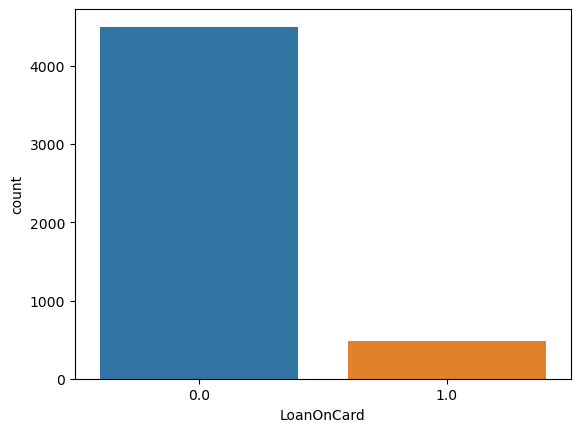

In [21]:
sns.countplot(x='LoanOnCard',data=df)

##### Imbalance Cure :

#### Model Training :

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

###### 1.Logistic Regression :

In [23]:
log = LogisticRegression(random_state=1)
log.fit(X_train,y_train)

LogisticRegression(random_state=1)

In [24]:
print('Training Score :',log.score(X_train,y_train))
print('Testing Score :',log.score(X_test,y_test))

Training Score : 0.9087779690189329
Testing Score : 0.9042838018741634


In [49]:
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay

In [26]:
y_pred = log.predict(X_test)

In [27]:
print('Classification report :')
print('-'*50)
print(classification_report(y_test,y_pred))

Classification report :
--------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.95      1341
         1.0       0.56      0.31      0.40       153

    accuracy                           0.90      1494
   macro avg       0.74      0.64      0.67      1494
weighted avg       0.89      0.90      0.89      1494



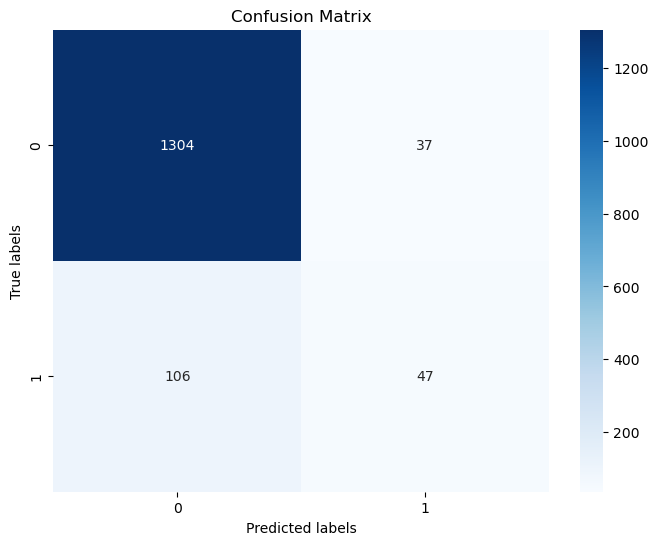

In [28]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

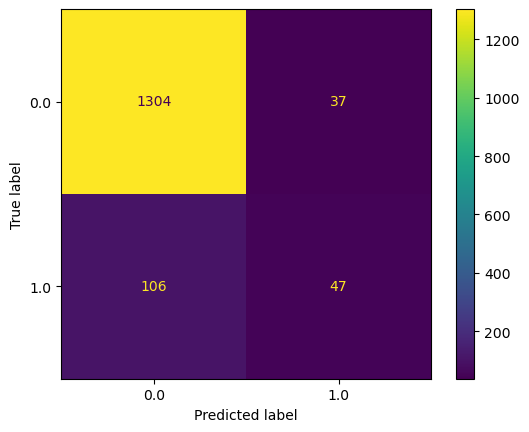

In [51]:
ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=log.classes_).plot()

###### 2.Naive Bayes :

In [29]:
nb = GaussianNB()
nb.fit(X_train,y_train)

GaussianNB()

In [30]:
print('Training Score :',nb.score(X_train,y_train))
print('Testing Score :',nb.score(X_test,y_test))

Training Score : 0.8924268502581756
Testing Score : 0.8848728246318608


In [31]:
train_pred = nb.predict(X_train)
test_pred = nb.predict(X_test)

In [32]:
from sklearn.metrics import roc_curve, auc

In [33]:
fpr1, tpr1, thresholds1 = roc_curve(y_train, train_pred)
roc_auc1 = auc(fpr1, tpr1)
gini1 = (2*roc_auc1)-1
print("Area under the ROC curve for train dataset : %f" % roc_auc1)
print("Gini Co-efficent for train dataset : %f" % gini1 )
print("--"*15)

Area under the ROC curve for train dataset : 0.759704
Gini Co-efficent for train dataset : 0.519407
------------------------------


In [34]:
fpr2, tpr2, thresholds2 = roc_curve(y_test, test_pred)
roc_auc2 = auc(fpr2, tpr2)
gini2 = (2*roc_auc2)-1
print("Area under the ROC curve for test dataset : %f" % roc_auc2)
print("Gini Co-efficent for train dataset : %f" % gini2 )

Area under the ROC curve for test dataset : 0.744791
Gini Co-efficent for train dataset : 0.489582


In [35]:
import pylab as pl

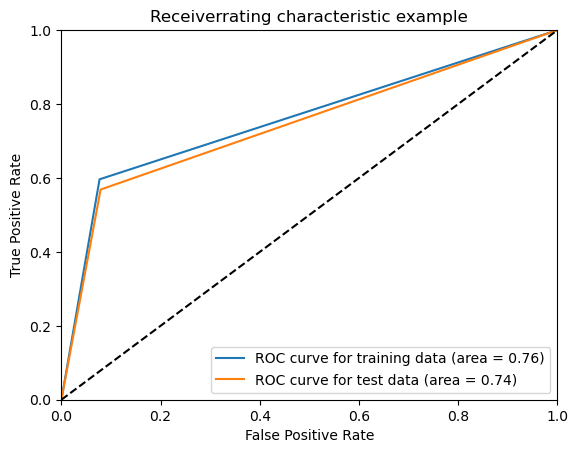

In [36]:
pl.clf()
pl.plot(fpr1, tpr1, label='ROC curve for training data (area = %0.2f)'
% roc_auc1)
pl.plot(fpr2, tpr2, label='ROC curve for test data (area = %0.2f)' %
roc_auc2)
pl.plot([0, 1], [0, 1], 'k--')
pl.xlim([0.0, 1.0])
pl.ylim([0.0, 1.0])
pl.xlabel('False Positive Rate')
pl.ylabel('True Positive Rate')
pl.title('Receiverrating characteristic example')
pl.legend(loc="lower right")
pl.show()

###### 3.Random Forest :

In [54]:
rf = RandomForestClassifier(n_estimators=10)
rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=10)

In [55]:
train_preds = rf.predict_proba(X_train)
test_preds = rf.predict_proba(X_test)

In [56]:
print('Training Score :',rf.score(X_train,y_train))
print('Testing Score :',rf.score(X_test,y_test))

Training Score : 0.9988525530694206
Testing Score : 0.9799196787148594


In [40]:
from sklearn.metrics import roc_auc_score

In [57]:
test_pred = rf.predict_proba(X_test)
train_pred = rf.predict_proba(X_train)

print("Training Performance Score :",round(roc_auc_score(y_train,train_pred[:,1]),4))
print("Testing Performance Score :",round(roc_auc_score(y_test,test_pred[:,1]),4))

Training Performance Score : 1.0
Testing Performance Score : 0.9784


In [58]:
from sklearn.model_selection import GridSearchCV

In [59]:
grid = {'n_estimators':[10,20,30],
        'max_depth':[7,8,9],
        'min_samples_leaf':[15,18,20,22,25]
           }

rf_model = RandomForestClassifier(random_state=1)
grid_search = GridSearchCV(estimator=rf_model,param_grid=grid,cv=5,verbose=True)
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=1),
             param_grid={'max_depth': [7, 8, 9],
                         'min_samples_leaf': [15, 18, 20, 22, 25],
                         'n_estimators': [10, 20, 30]},
             verbose=True)

In [60]:
grid_search.best_estimator_

RandomForestClassifier(max_depth=9, min_samples_leaf=15, n_estimators=20,
                       random_state=1)

Final Model :

In [61]:
rf = RandomForestClassifier(n_estimators=20,max_depth=9,min_samples_leaf=15)
rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=9, min_samples_leaf=15, n_estimators=20)

In [62]:
print('Training Score :',rf.score(X_train,y_train))
print('Testing Score :',rf.score(X_test,y_test))

Training Score : 0.9825014343086632
Testing Score : 0.9725568942436412


In [63]:
test_pred = rf.predict_proba(X_test)
train_pred = rf.predict_proba(X_train)

In [64]:
print("Training Performance Score :",round(roc_auc_score(y_train,train_pred[:,1]),4))
print("Testing Performance Score :",round(roc_auc_score(y_test,test_pred[:,1]),4))

Training Performance Score : 0.9976
Testing Performance Score : 0.9872
